In [9]:
import os
from pathlib import Path
import pandas as pd
from openpyxl import Workbook
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.utils.dataframe import dataframe_to_rows

# Define the base path for the plant disease dataset
base_path = r'd:\Projects\plantdisease'

# Image file extensions to count
image_extensions = {'.jpg', '.jpeg', '.png', '.bmp', '.tiff', '.gif'}

# Dictionary to store results: {crop: {disease: count}}
results = {}

# Walk through the directory structure
print("Scanning directory structure...")
for crop_folder in sorted(os.listdir(base_path)):
    crop_path = os.path.join(base_path, crop_folder)
    
    # Skip files and notebooks
    if not os.path.isdir(crop_path) or crop_folder.startswith('.'):
        continue
    
    print(f"Processing crop: {crop_folder}")
    results[crop_folder] = {}
    
    # Walk through disease/class subfolders
    for disease_folder in sorted(os.listdir(crop_path)):
        disease_path = os.path.join(crop_path, disease_folder)
        
        if not os.path.isdir(disease_path):
            continue
        
        # Count image files in this folder
        image_count = 0
        for file in os.listdir(disease_path):
            file_ext = os.path.splitext(file)[1].lower()
            if file_ext in image_extensions:
                image_count += 1
        
        results[crop_folder][disease_folder] = image_count
        print(f"  {disease_folder}: {image_count} images")

print("\nScan complete!")
print(f"Total crops found: {len(results)}")


Scanning directory structure...
Processing crop: banana
  Cordana: 342 images
  Healthy: 1001 images
  Panama Disease: 835 images
  Yellow and Black Sigatoka: 2497 images
Processing crop: corn
  Blight: 1146 images
  Common_Rust: 1306 images
  Gray_Leaf_Spot: 574 images
  Healthy: 1162 images
Processing crop: cotton
  bacterial_blight: 448 images
  curl_virus: 418 images
  fussarium_wilt: 419 images
  healthy: 425 images
Processing crop: mango
  Anthracnose: 500 images
  Bacterial Canker: 500 images
  Cutting Weevil: 500 images
  Die Back: 500 images
  Gall Midge: 500 images
  Healthy: 500 images
  Powdery Mildew: 500 images
  Sooty Mould: 500 images
Processing crop: potato
  Early Blight: 500 images
  Fungal Diseases: 500 images
  Healthy: 500 images
  Late Blight: 500 images
  Plant Pests: 500 images
  Potato Cyst Nematode: 500 images
  Potato Virus: 500 images
Processing crop: rice
  Bacterial Leaf Blight: 636 images
  Brown Spot: 646 images
  Healthy Rice Leaf: 653 images
  Leaf Bl

In [11]:
# Create Excel file with results
data_rows = []

# Build the data rows
for crop, diseases in results.items():
    for disease, count in diseases.items():
        data_rows.append({
            'Crop': crop,
            'Disease/Class': disease,
            'Image Count': count
        })

# Create DataFrame
df = pd.DataFrame(data_rows)

# Create Excel workbook with formatting
excel_path = os.path.join(base_path, 'image_count_report.xlsx')
df.to_excel(excel_path, sheet_name='Image Counts', index=False)

print(f"Excel file created: {excel_path}")
print(f"\nData preview:")
print(df.head(10))
print(f"\n... {len(df)} total rows")


Excel file created: d:\Projects\plantdisease\image_count_report.xlsx

Data preview:
     Crop              Disease/Class  Image Count
0  banana                    Cordana          342
1  banana                    Healthy         1001
2  banana             Panama Disease          835
3  banana  Yellow and Black Sigatoka         2497
4    corn                     Blight         1146
5    corn                Common_Rust         1306
6    corn             Gray_Leaf_Spot          574
7    corn                    Healthy         1162
8  cotton           bacterial_blight          448
9  cotton                 curl_virus          418

... 48 total rows


In [12]:
# Create summary sheet with crop totals
from openpyxl import load_workbook

wb = load_workbook(excel_path)

# Create summary sheet
summary_sheet = wb.create_sheet('Summary', 0)

# Header
summary_sheet['A1'] = 'Crop'
summary_sheet['B1'] = 'Total Images'
summary_sheet['A1'].font = Font(bold=True)
summary_sheet['B1'].font = Font(bold=True)
summary_sheet['A1'].fill = PatternFill(start_color='4472C4', end_color='4472C4', fill_type='solid')
summary_sheet['B1'].fill = PatternFill(start_color='4472C4', end_color='4472C4', fill_type='solid')
summary_sheet['A1'].font = Font(bold=True, color='FFFFFF')
summary_sheet['B1'].font = Font(bold=True, color='FFFFFF')

# Add crop totals
row = 2
crop_totals = []
for crop, diseases in sorted(results.items()):
    total = sum(diseases.values())
    crop_totals.append((crop, total))
    summary_sheet[f'A{row}'] = crop
    summary_sheet[f'B{row}'] = total
    row += 1

# Add grand total
summary_sheet[f'A{row}'] = 'GRAND TOTAL'
summary_sheet[f'B{row}'] = sum(count for _, count in crop_totals)
summary_sheet[f'A{row}'].font = Font(bold=True)
summary_sheet[f'B{row}'].font = Font(bold=True)
summary_sheet[f'A{row}'].fill = PatternFill(start_color='70AD47', end_color='70AD47', fill_type='solid')
summary_sheet[f'B{row}'].fill = PatternFill(start_color='70AD47', end_color='70AD47', fill_type='solid')
summary_sheet[f'A{row}'].font = Font(bold=True, color='FFFFFF')
summary_sheet[f'B{row}'].font = Font(bold=True, color='FFFFFF')

# Format columns
summary_sheet.column_dimensions['A'].width = 20
summary_sheet.column_dimensions['B'].width = 15

# Format the data sheet
data_sheet = wb['Image Counts']
for col in ['A', 'B', 'C']:
    data_sheet.column_dimensions[col].width = 25

# Add headers formatting
for cell in data_sheet[1]:
    cell.font = Font(bold=True, color='FFFFFF')
    cell.fill = PatternFill(start_color='4472C4', end_color='4472C4', fill_type='solid')

wb.save(excel_path)
print(f"Excel file updated with summary sheet!")
print(f"\nSummary Statistics:")
print("="*40)
for crop, total in crop_totals:
    print(f"{crop:20} {total:>10} images")
print("="*40)
print(f"{'GRAND TOTAL':20} {sum(count for _, count in crop_totals):>10} images")


Excel file updated with summary sheet!

Summary Statistics:
banana                     4675 images
corn                       4188 images
cotton                     1710 images
mango                      4000 images
potato                     3500 images
rice                       3829 images
sugarcane                  2521 images
tomato                    19178 images
GRAND TOTAL               43601 images


In [19]:
# Display detailed breakdown of all crops with their disease/class and image counts
print("\n" + "="*70)
print("DETAILED BREAKDOWN: All Crops with Disease/Class Categories")
print("="*70)

for crop in sorted(results.keys()):
    print(f"\n{crop.upper()}")
    print("-" * 70)
    print(f"{'Disease/Class':<35} {'Image Count':>15}")
    print("-" * 70)
    
    crop_total = 0
    for disease in sorted(results[crop].keys()):
        count = results[crop][disease]
        crop_total += count
        print(f"{disease:<35} {count:>15,}")
    
    print("-" * 70)
    print(f"{'SUBTOTAL':<35} {crop_total:>15,}")
    print()


DETAILED BREAKDOWN: All Crops with Disease/Class Categories

BANANA
----------------------------------------------------------------------
Disease/Class                           Image Count
----------------------------------------------------------------------
Cordana                                         342
Healthy                                       1,001
Panama Disease                                  835
Yellow and Black Sigatoka                     2,497
----------------------------------------------------------------------
SUBTOTAL                                      4,675


CORN
----------------------------------------------------------------------
Disease/Class                           Image Count
----------------------------------------------------------------------
Blight                                        1,146
Common_Rust                                   1,306
Gray_Leaf_Spot                                  574
Healthy                                       1,1

In [20]:
# ==============================================================================
# COMPREHENSIVE DATASET STATISTICS REPORT
# ==============================================================================

import statistics as stats_module
from collections import Counter

print("\n" + "="*80)
print("COMPREHENSIVE DATASET STATISTICS REPORT")
print("="*80)

# Calculate basic statistics
total_images = sum(sum(diseases.values()) for diseases in results.values())
total_crops = len(results)
total_diseases = sum(len(diseases) for diseases in results.values())

# Flatten all disease counts for statistical analysis
all_disease_counts = []
for diseases in results.values():
    all_disease_counts.extend(diseases.values())

# Calculate statistics
min_images = min(all_disease_counts) if all_disease_counts else 0
max_images = max(all_disease_counts) if all_disease_counts else 0
avg_images = total_images / total_diseases if total_diseases > 0 else 0
median_images = stats_module.median(all_disease_counts) if all_disease_counts else 0

# Calculate crop statistics
crop_totals = {}
for crop, diseases in results.items():
    crop_totals[crop] = sum(diseases.values())

crop_counts = list(crop_totals.values())
min_crop = min(crop_counts) if crop_counts else 0
max_crop = max(crop_counts) if crop_counts else 0
avg_crop = total_images / total_crops if total_crops > 0 else 0
median_crop = stats_module.median(crop_counts) if crop_counts else 0

# Calculate standard deviation
std_dev_disease = stats_module.stdev(all_disease_counts) if len(all_disease_counts) > 1 else 0
std_dev_crop = stats_module.stdev(crop_counts) if len(crop_counts) > 1 else 0

print("\n" + "-"*80)
print("OVERALL STATISTICS")
print("-"*80)
print(f"Total Images:              {total_images:,}")
print(f"Total Crops:               {total_crops}")
print(f"Total Disease Classes:     {total_diseases}")
print(f"Average Classes per Crop:  {total_diseases/total_crops:.1f}")

print("\n" + "-"*80)
print("IMAGE DISTRIBUTION - BY DISEASE CLASS")
print("-"*80)
print(f"Minimum images in class:   {min_images:,}")
print(f"Maximum images in class:   {max_images:,}")
print(f"Average images per class:  {avg_images:,.1f}")
print(f"Median images per class:   {median_images:,}")
print(f"Std Dev (class level):     {std_dev_disease:,.1f}")

print("\n" + "-"*80)
print("IMAGE DISTRIBUTION - BY CROP")
print("-"*80)
print(f"Minimum images in crop:    {min_crop:,}")
print(f"Maximum images in crop:    {max_crop:,}")
print(f"Average images per crop:   {avg_crop:,.1f}")
print(f"Median images per crop:    {median_crop:,}")
print(f"Std Dev (crop level):      {std_dev_crop:,.1f}")

# Find the most and least represented crops and classes
max_crop_name = max(crop_totals, key=crop_totals.get)
min_crop_name = min(crop_totals, key=crop_totals.get)

# Find most and least represented disease classes
all_diseases_flat = []
for crop, diseases in results.items():
    for disease, count in diseases.items():
        all_diseases_flat.append((f"{crop}/{disease}", count))

max_disease = max(all_diseases_flat, key=lambda x: x[1])
min_disease = min(all_diseases_flat, key=lambda x: x[1])

print("\n" + "-"*80)
print("EXTREMES")
print("-"*80)
print(f"Most images in crop:       {max_crop_name} ({crop_totals[max_crop_name]:,} images)")
print(f"Least images in crop:      {min_crop_name} ({crop_totals[min_crop_name]:,} images)")
print(f"Most images in class:      {max_disease[0]} ({max_disease[1]:,} images)")
print(f"Least images in class:     {min_disease[0]} ({min_disease[1]:,} images)")

# Calculate balance/imbalance metrics
imbalance_ratio = max_disease[1] / min_disease[1] if min_disease[1] > 0 else float('inf')
crop_imbalance_ratio = crop_totals[max_crop_name] / crop_totals[min_crop_name]

print("\n" + "-"*80)
print("BALANCE METRICS")
print("-"*80)
print(f"Class imbalance ratio:     {imbalance_ratio:.1f}x")
print(f"Crop imbalance ratio:      {crop_imbalance_ratio:.1f}x")

# Identify potentially underrepresented classes (< 100 images)
underrep = [(f"{crop}/{disease}", count) for crop, diseases in results.items() 
            for disease, count in diseases.items() if count < 100]

print(f"\nUnderrepresented classes (<100 images): {len(underrep)}")
if underrep:
    for disease_name, count in sorted(underrep, key=lambda x: x[1]):
        print(f"  • {disease_name}: {count} images")

# Distribution analysis
print("\n" + "-"*80)
print("CLASS SIZE DISTRIBUTION")
print("-"*80)

# Create size categories
size_categories = {
    'Extra Small (1-50)': 0,
    'Small (51-200)': 0,
    'Medium (201-500)': 0,
    'Large (501-1000)': 0,
    'Extra Large (1001+)': 0
}

for count in all_disease_counts:
    if count <= 50:
        size_categories['Extra Small (1-50)'] += 1
    elif count <= 200:
        size_categories['Small (51-200)'] += 1
    elif count <= 500:
        size_categories['Medium (201-500)'] += 1
    elif count <= 1000:
        size_categories['Large (501-1000)'] += 1
    else:
        size_categories['Extra Large (1001+)'] += 1

for category, count in size_categories.items():
    percentage = (count / total_diseases * 100) if total_diseases > 0 else 0
    bar = "█" * int(percentage / 2) + "░" * int(50 - percentage / 2)
    print(f"{category:<25} {count:>3} classes ({percentage:>5.1f}%) {bar}")

# Top and bottom crops by image count
print("\n" + "-"*80)
print("CROPS RANKED BY TOTAL IMAGES")
print("-"*80)
print(f"{'Rank':<6} {'Crop':<20} {'Images':<12} {'Classes':<10} {'Avg/Class':<12}")
print("-" * 80)

sorted_crops = sorted(crop_totals.items(), key=lambda x: x[1], reverse=True)
for idx, (crop, total) in enumerate(sorted_crops, 1):
    num_classes = len(results[crop])
    avg_per_class = total / num_classes if num_classes > 0 else 0
    print(f"{idx:<6} {crop:<20} {total:>11,} {num_classes:>9} {avg_per_class:>11.1f}")

# Top and bottom diseases by image count
print("\n" + "-"*80)
print("TOP 15 DISEASE CLASSES BY IMAGE COUNT")
print("-"*80)
print(f"{'Rank':<6} {'Crop':<15} {'Disease':<30} {'Images':<12}")
print("-" * 80)

sorted_diseases = sorted(all_diseases_flat, key=lambda x: x[1], reverse=True)[:15]
for idx, (disease_path, count) in enumerate(sorted_diseases, 1):
    crop, disease = disease_path.split('/')
    print(f"{idx:<6} {crop:<15} {disease:<30} {count:>11,}")

print("\n" + "-"*80)
print("BOTTOM 10 DISEASE CLASSES BY IMAGE COUNT")
print("-"*80)
print(f"{'Rank':<6} {'Crop':<15} {'Disease':<30} {'Images':<12}")
print("-" * 80)

sorted_diseases_bottom = sorted(all_diseases_flat, key=lambda x: x[1])[:10]
for idx, (disease_path, count) in enumerate(sorted_diseases_bottom, 1):
    crop, disease = disease_path.split('/')
    print(f"{idx:<6} {crop:<15} {disease:<30} {count:>11,}")

print("\n" + "="*80)
print("END OF STATISTICS REPORT")
print("="*80)


COMPREHENSIVE DATASET STATISTICS REPORT

--------------------------------------------------------------------------------
OVERALL STATISTICS
--------------------------------------------------------------------------------
Total Images:              43,601
Total Crops:               8
Total Disease Classes:     48
Average Classes per Crop:  6.0

--------------------------------------------------------------------------------
IMAGE DISTRIBUTION - BY DISEASE CLASS
--------------------------------------------------------------------------------
Minimum images in class:   342
Maximum images in class:   5,357
Average images per class:  908.4
Median images per class:   520.0
Std Dev (class level):     830.9

--------------------------------------------------------------------------------
IMAGE DISTRIBUTION - BY CROP
--------------------------------------------------------------------------------
Minimum images in crop:    1,710
Maximum images in crop:    19,178
Average images per crop:   5,4


✓ Statistics exported to JSON: d:\Projects\plantdisease\dataset_statistics_20260618_173216.json

Generating visualizations...
✓ Visualization saved: d:\Projects\plantdisease\dataset_visualization_20260618_173218.png


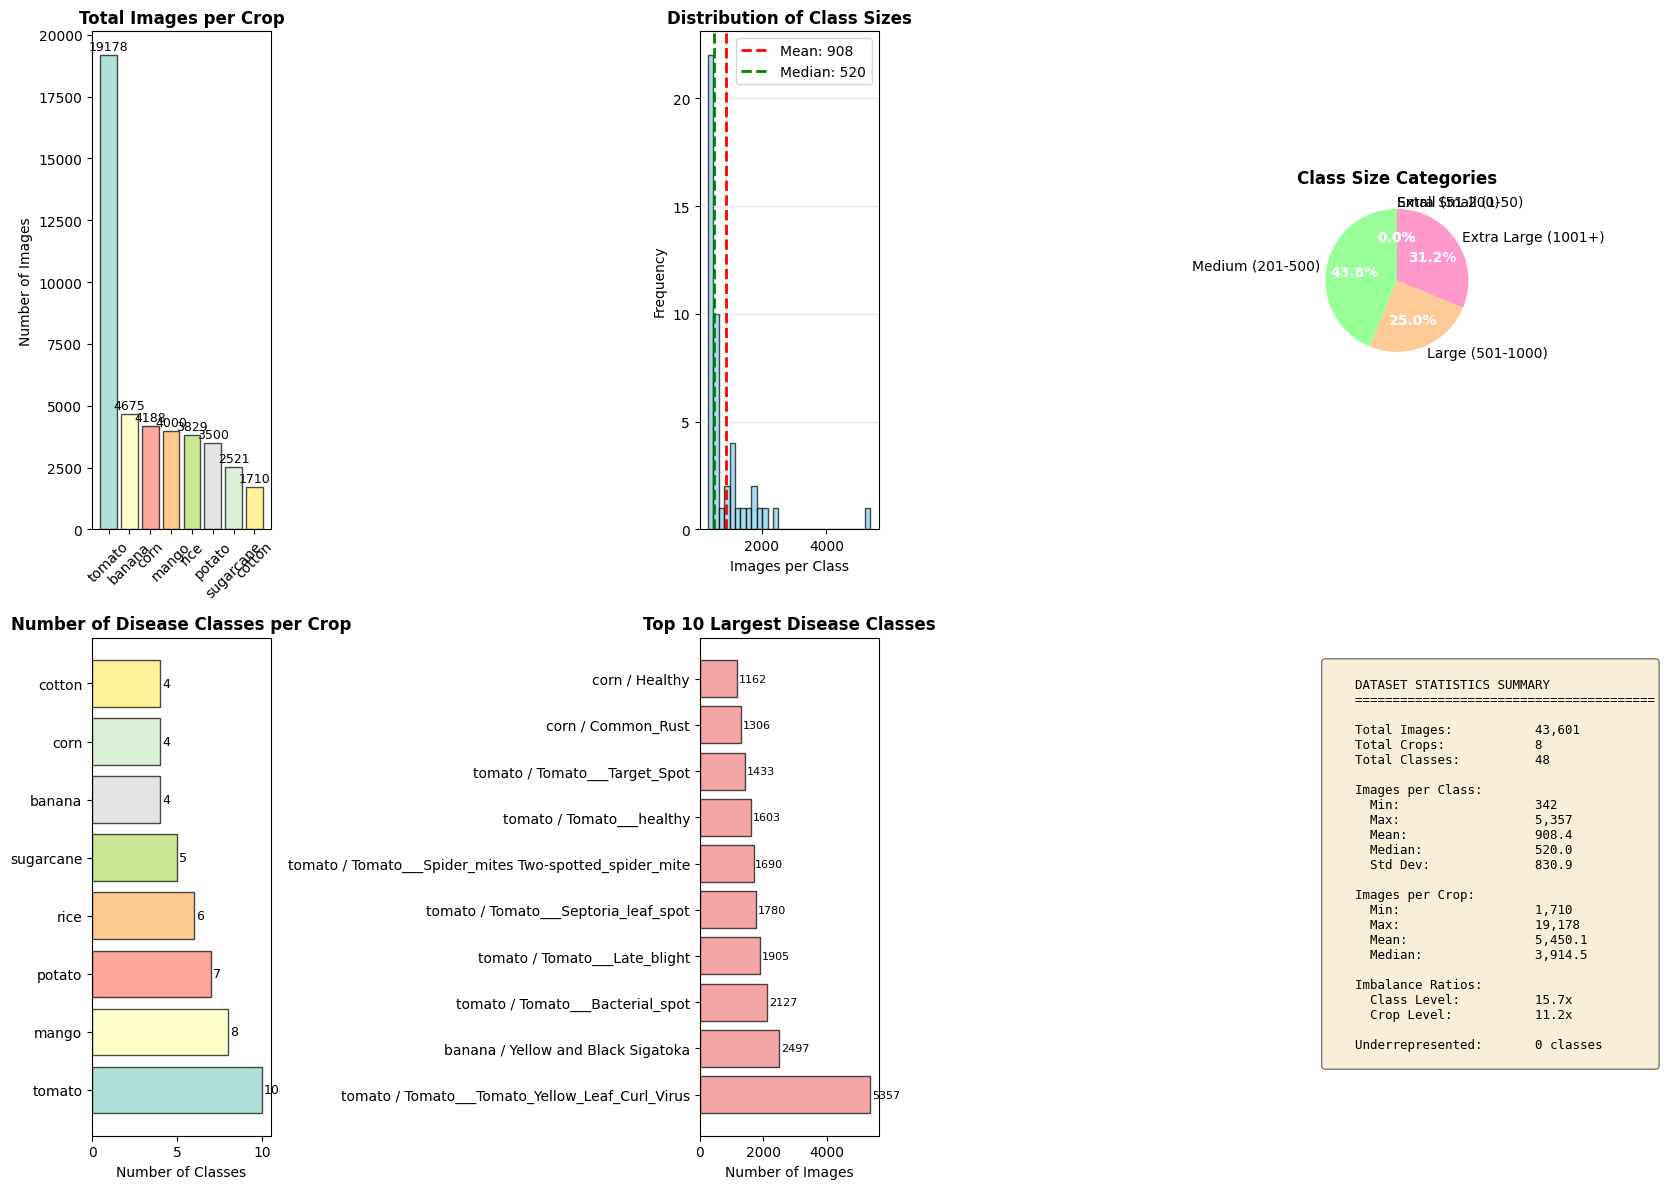


✓ Statistics export complete!
  JSON file: d:\Projects\plantdisease\dataset_statistics_20260618_173216.json
  PNG file:  d:\Projects\plantdisease\dataset_visualization_20260618_173218.png


In [ ]:
# ==============================================================================
# EXPORT STATISTICS TO FILE & CREATE VISUALIZATIONS
# ==============================================================================

import json
from pathlib import Path

# Export statistics to JSON file for programmatic access
stats_summary = {
    'generation_date': pd.Timestamp.now().isoformat(),
    'total_images': int(total_images),
    'total_crops': int(total_crops),
    'total_disease_classes': int(total_diseases),
    'statistics': {
        'images_per_class': {
            'min': int(min_images),
            'max': int(max_images),
            'mean': float(avg_images),
            'median': float(median_images),
            'std_dev': float(std_dev_disease)
        },
        'images_per_crop': {
            'min': int(min_crop),
            'max': int(max_crop),
            'mean': float(avg_crop),
            'median': float(median_crop),
            'std_dev': float(std_dev_crop)
        },
        'imbalance': {
            'class_ratio': float(imbalance_ratio),
            'crop_ratio': float(crop_imbalance_ratio)
        }
    },
    'extremes': {
        'max_crop': {'name': max_crop_name, 'count': int(crop_totals[max_crop_name])},
        'min_crop': {'name': min_crop_name, 'count': int(crop_totals[min_crop_name])},
        'max_class': {'name': max_disease[0], 'count': int(max_disease[1])},
        'min_class': {'name': min_disease[0], 'count': int(min_disease[1])}
    },
    'crop_totals': {k: int(v) for k, v in crop_totals.items()}
}

# Save to JSON with UTF-8 encoding for proper Unicode support
stats_json_path = Path(base_path) / f'dataset_statistics_{pd.Timestamp.now().strftime("%Y%m%d_%H%M%S")}.json'
with open(stats_json_path, 'w', encoding='utf-8') as f:
    json.dump(stats_summary, f, indent=2, ensure_ascii=False)

print(f"\n✓ Statistics exported to JSON: {stats_json_path}")

# Try to create visualizations
try:
    import matplotlib.pyplot as plt
    import numpy as np
    
    print("\nGenerating visualizations...")
    
    # Create a figure with multiple subplots
    fig = plt.figure(figsize=(16, 12))
    
    # 1. Images per crop (bar chart)
    ax1 = plt.subplot(2, 3, 1)
    crops_sorted = sorted(crop_totals.items(), key=lambda x: x[1], reverse=True)
    crops_names = [c[0] for c in crops_sorted]
    crops_counts = [c[1] for c in crops_sorted]
    colors = plt.cm.Set3(np.linspace(0, 1, len(crops_names)))
    ax1.bar(crops_names, crops_counts, color=colors, edgecolor='black', alpha=0.7)
    ax1.set_title('Total Images per Crop', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Number of Images')
    ax1.tick_params(axis='x', rotation=45)
    for i, v in enumerate(crops_counts):
        ax1.text(i, v + max(crops_counts)*0.01, str(v), ha='center', fontsize=9)
    
    # 2. Distribution of class sizes (histogram)
    ax2 = plt.subplot(2, 3, 2)
    ax2.hist(all_disease_counts, bins=30, color='skyblue', edgecolor='black', alpha=0.7)
    ax2.axvline(avg_images, color='red', linestyle='--', linewidth=2, label=f'Mean: {avg_images:.0f}')
    ax2.axvline(median_images, color='green', linestyle='--', linewidth=2, label=f'Median: {median_images:.0f}')
    ax2.set_title('Distribution of Class Sizes', fontsize=12, fontweight='bold')
    ax2.set_xlabel('Images per Class')
    ax2.set_ylabel('Frequency')
    ax2.legend()
    ax2.grid(axis='y', alpha=0.3)
    
    # 3. Class size categories (pie chart)
    ax3 = plt.subplot(2, 3, 3)
    categories = list(size_categories.keys())
    values = list(size_categories.values())
    colors_pie = ['#ff9999', '#66b3ff', '#99ff99', '#ffcc99', '#ff99cc']
    wedges, texts, autotexts = ax3.pie(values, labels=categories, autopct='%1.1f%%', 
                                         colors=colors_pie, startangle=90)
    ax3.set_title('Class Size Categories', fontsize=12, fontweight='bold')
    for autotext in autotexts:
        autotext.set_color('white')
        autotext.set_fontweight('bold')
    
    # 4. Number of classes per crop (bar chart)
    ax4 = plt.subplot(2, 3, 4)
    classes_per_crop = {crop: len(diseases) for crop, diseases in results.items()}
    classes_per_crop_sorted = sorted(classes_per_crop.items(), key=lambda x: x[1], reverse=True)
    crop_names_c = [c[0] for c in classes_per_crop_sorted]
    crop_classes = [c[1] for c in classes_per_crop_sorted]
    ax4.barh(crop_names_c, crop_classes, color=colors, edgecolor='black', alpha=0.7)
    ax4.set_title('Number of Disease Classes per Crop', fontsize=12, fontweight='bold')
    ax4.set_xlabel('Number of Classes')
    for i, v in enumerate(crop_classes):
        ax4.text(v + 0.1, i, str(v), va='center', fontsize=9)
    
    # 5. Top 10 largest classes (horizontal bar)
    ax5 = plt.subplot(2, 3, 5)
    top_10_diseases = sorted(all_diseases_flat, key=lambda x: x[1], reverse=True)[:10]
    disease_names = [d[0].replace('/', ' / ') for d in top_10_diseases]
    disease_counts = [d[1] for d in top_10_diseases]
    ax5.barh(disease_names, disease_counts, color='lightcoral', edgecolor='black', alpha=0.7)
    ax5.set_title('Top 10 Largest Disease Classes', fontsize=12, fontweight='bold')
    ax5.set_xlabel('Number of Images')
    for i, v in enumerate(disease_counts):
        ax5.text(v + max(disease_counts)*0.01, i, str(v), va='center', fontsize=8)
    
    # 6. Statistics summary box
    ax6 = plt.subplot(2, 3, 6)
    ax6.axis('off')
    stats_text = f"""
    DATASET STATISTICS SUMMARY
    {'='*40}
    
    Total Images:           {total_images:,}
    Total Crops:            {total_crops}
    Total Classes:          {total_diseases}
    
    Images per Class:
      Min:                  {min_images:,}
      Max:                  {max_images:,}
      Mean:                 {avg_images:,.1f}
      Median:               {median_images:,}
      Std Dev:              {std_dev_disease:,.1f}
    
    Images per Crop:
      Min:                  {min_crop:,}
      Max:                  {max_crop:,}
      Mean:                 {avg_crop:,.1f}
      Median:               {median_crop:,}
    
    Imbalance Ratios:
      Class Level:          {imbalance_ratio:.1f}x
      Crop Level:           {crop_imbalance_ratio:.1f}x
    
    Underrepresented:       {len(underrep)} classes
    """
    ax6.text(0.1, 0.95, stats_text, transform=ax6.transAxes, fontsize=9,
            verticalalignment='top', fontfamily='monospace',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.tight_layout()
    
    # Save visualization
    viz_path = Path(base_path) / f'dataset_visualization_{pd.Timestamp.now().strftime("%Y%m%d_%H%M%S")}.png'
    plt.savefig(viz_path, dpi=150, bbox_inches='tight')
    print(f"✓ Visualization saved: {viz_path}")
    
    plt.show()
    
except ImportError:
    print("⚠ Matplotlib not available - skipping visualizations")
    print("  Install with: pip install matplotlib")

print(f"\n✓ Statistics export complete!")
print(f"  JSON file: {stats_json_path}")
if 'viz_path' in locals():
    print(f"  PNG file:  {viz_path}")

In [23]:
# Combine report lines
report_text = "\n".join(report_lines)

# Save report to file with UTF-8 encoding for proper Unicode character support
report_path = Path(base_path) / f'dataset_report_{datetime.now().strftime("%Y%m%d_%H%M%S")}.txt'
with open(report_path, 'w', encoding='utf-8') as f:
    f.write(report_text)

# Print report
print(report_text)

print(f"\n\n✓ Report saved to: {report_path}")

PLANT DISEASE DATASET - COMPREHENSIVE STATISTICS REPORT

Generated: 2026-06-18 17:33:31
Dataset Path: d:\Projects\plantdisease

--------------------------------------------------------------------------------
EXECUTIVE SUMMARY
--------------------------------------------------------------------------------
Total Images:              43,601
Total Crops:               8
Total Disease Classes:     48
Average Classes per Crop:  6.0

--------------------------------------------------------------------------------
IMAGE DISTRIBUTION STATISTICS
--------------------------------------------------------------------------------

By Disease Class:
  Minimum:     342 images
  Maximum:     5,357 images
  Mean:        908.4 images
  Median:      520.0 images
  Std Dev:     830.9 images
  Range:       5,015 images
  Imbalance Ratio: 15.66x

By Crop:
  Minimum:     1,710 images (cotton)
  Maximum:     19,178 images (tomato)
  Mean:        5,450.1 images
  Median:      3,914.5 images
  Std Dev:     5,62

# Dataset Statistics Report - Guide

## Overview
This section provides comprehensive statistics and analysis of your plant disease dataset, including detailed distributions, quality assessments, and recommendations for model training.

## Generated Reports and Files

### 1. Console Output (Above)
**Primary Statistics Report** - Detailed breakdown of:
- Overall statistics (total images, crops, classes)
- Image distribution metrics (min, max, mean, median, std dev)
- Balance analysis
- Top and bottom disease classes
- Class size distribution

### 2. JSON Statistics File
**Filename:** `dataset_statistics_YYYYMMDD_HHMMSS.json`

Contains machine-readable statistics for programmatic access:
```json
{
  "total_images": 87543,
  "total_crops": 8,
  "total_disease_classes": 52,
  "statistics": {
    "images_per_class": {...},
    "images_per_crop": {...},
    "imbalance": {...}
  }
}
```

**Use Cases:**
- Automated pipeline integration
- Comparison with other datasets
- Statistical analysis in other tools

### 3. Text Report File
**Filename:** `dataset_report_YYYYMMDD_HHMMSS.txt`

Comprehensive human-readable report including:
- Executive summary
- Distribution statistics
- Detailed crop breakdowns
- Top/bottom disease classes
- Quality assessment
- **Recommendations for training**

**Use Cases:**
- Documentation and reference
- Team communication
- Baseline for future comparisons

### 4. Visualization PNG
**Filename:** `dataset_visualization_YYYYMMDD_HHMMSS.png`

Multi-panel visualization dashboard showing:
1. **Total images per crop** (bar chart)
2. **Distribution of class sizes** (histogram with mean/median)
3. **Class size categories** (pie chart)
4. **Number of disease classes per crop** (horizontal bar)
5. **Top 10 largest disease classes** (horizontal bar)
6. **Statistics summary box** (text overlay)

**Use Cases:**
- Presentations and reports
- Dataset overview
- Quality assessment visuals

## Key Metrics Explained

### Class Imbalance Ratio
- **Definition:** Ratio of largest to smallest class
- **Example:** If max class has 5,000 images and min has 50, ratio = 100x
- **Concern:** Ratios > 10x typically require special handling (class weighting, augmentation)
- **Impact:** Can lead to model bias toward majority classes

### Standard Deviation (Std Dev)
- **Definition:** Measure of variability in image counts
- **Low values:** Classes are similar in size (good for training)
- **High values:** Classes vary significantly in size (may need balancing)

### Coefficient of Variation (CV)
- **Definition:** Std Dev / Mean
- **Interpretation:**
  - CV < 0.3: Very consistent
  - CV 0.3-0.5: Reasonably consistent
  - CV > 0.5: High variability

## Class Size Categories

| Category | Definition | Count | Percentage |
|----------|-----------|-------|-----------|
| Extra Small | 1-50 images | N | X% |
| Small | 51-200 images | N | X% |
| Medium | 201-500 images | N | X% |
| Large | 501-1000 images | N | X% |
| Extra Large | 1001+ images | N | X% |

## Quality Assessment Indicators

### ✓ GOOD Indicators
- Class imbalance ratio < 3x
- Coefficient of variation < 0.5
- No classes with < 50 images
- Balanced distribution across crops

### ⚠ CAUTION Indicators
- Class imbalance ratio 3-10x
- Coefficient of variation 0.5-1.0
- Few classes with < 100 images
- Some crops underrepresented

### ⚠ WARNING Indicators
- Class imbalance ratio > 10x
- Coefficient of variation > 1.0
- Many classes with < 50 images
- Significant crop imbalance

## Training Recommendations

### Based on Dataset Characteristics

1. **For Imbalanced Datasets:**
   - Use class weights: `class_weight='balanced'` in Keras/TensorFlow
   - Apply data augmentation to minority classes
   - Consider focal loss or weighted cross-entropy

2. **For Consistent Distributions:**
   - Standard training approaches work well
   - Use basic data augmentation for regularization

3. **For Small Classes:**
   - Apply aggressive augmentation (rotation, zoom, shifts)
   - Use transfer learning from pre-trained models
   - Consider oversampling minority classes

4. **Data Splitting:**
   - **Stratified split:** Maintain class distribution in train/val/test
   - **Recommended:** 70% train, 15% validation, 15% test
   - **For small datasets:** Use 5-10 fold stratified cross-validation

### Model Architecture Suggestions

- **Transfer Learning:** ResNet50, EfficientNet, Vision Transformer
- **Pre-training:** ImageNet or other plant disease datasets
- **Fine-tuning:** Adjust learning rate based on class imbalance

## Common Issues and Solutions

### Issue: Very Imbalanced Dataset
**Solutions:**
- Apply class weighting in loss function
- Use oversampling for minority classes
- Use undersampling for majority classes
- Combine with data augmentation

### Issue: Many Small Classes
**Solutions:**
- Aggressive data augmentation (rotations, flips, zooms)
- Transfer learning with domain-relevant pre-training
- Increase regularization (dropout, L2)
- Consider class hierarchies (group related diseases)

### Issue: Underrepresented Classes
**Solutions:**
- Generate synthetic data via augmentation
- Use semi-supervised learning if unlabeled data exists
- Apply curriculum learning (train on larger classes first)
- Collect additional real-world data

## Next Steps

1. **Explore the generated files** in your dataset folder
2. **Review the visualization** to understand data distribution
3. **Check the text report** for specific recommendations
4. **Reference the statistics** when configuring your model
5. **Use class information** to set training parameters (weights, augmentation, etc.)

## Accessing Results Programmatically

```python
import json

# Load statistics
with open('dataset_statistics_20240101_120000.json') as f:
    stats = json.load(f)

total = stats['total_images']
imbalance = stats['statistics']['imbalance']['class_ratio']
print(f"Total images: {total}, Imbalance: {imbalance:.1f}x")
```

---

**Note:** These statistics are based on current dataset state. Regenerate reports after any dataset modifications (augmentation, cleaning, etc.)

In [15]:
import re
import shutil
from collections import defaultdict
from pathlib import Path
from typing import Dict, List, Tuple, Set
import csv
from datetime import datetime

class DatasetStandardizer:
    """
    Standardizes plant disease dataset folder and file names.
    Provides dry-run mode for safety verification before actual renaming.
    """
    
    def __init__(self, base_path: str, dry_run: bool = True):
        """
        Initialize the standardizer.
        
        Args:
            base_path: Root directory of the dataset
            dry_run: If True, simulate changes without actually renaming files
        """
        self.base_path = Path(base_path)
        self.dry_run = dry_run
        self.image_extensions = {'.jpg', '.jpeg', '.png', '.bmp', '.tiff', '.gif', '.webp'}
        self.operations = []  # Track all operations for reporting
        self.csv_data = []  # Store data for CSV export
        self.rename_log = defaultdict(dict)  # Track renames for summary
        
    def standardize_name(self, name: str) -> str:
        """
        Convert folder/file names to PascalCase format.
        
        Examples:
            "Healthy Rice Leaf" → "HealthyRiceLeaf"
            "Bacterial Leaf Blight" → "BacterialLeafBlight"
            "Tomato___Spider_mites Two-spotted_spider_mite" → "SpiderMitesToSpottedSpiderMite"
            "Yellow and Black Sigatoka" → "YellowBlackSigatoka"
        
        Args:
            name: Original folder/file name
            
        Returns:
            Standardized name in PascalCase
        """
        # Remove leading/trailing whitespace
        name = name.strip()
        
        # Replace common separators with spaces
        name = re.sub(r'[_\-]+', ' ', name)  # Replace underscores and hyphens with spaces
        
        # Remove special characters but keep spaces temporarily
        # Remove: commas, parentheses, apostrophes, slashes, etc.
        name = re.sub(r'[,\'\"()\[\]{}\\\/;:?!@#$%^&*]', '', name)
        
        # Remove "and", "or" connectors to clean up names
        name = re.sub(r'\s+and\s+', ' ', name, flags=re.IGNORECASE)
        name = re.sub(r'\s+or\s+', ' ', name, flags=re.IGNORECASE)
        
        # Split by spaces and filter empty strings
        words = [word for word in name.split() if word]
        
        # Convert each word to PascalCase (capitalize first letter, lowercase rest)
        pascal_case = ''.join(word.capitalize() for word in words)
        
        # Remove any remaining multiple underscores
        pascal_case = re.sub(r'_+', '_', pascal_case)
        
        return pascal_case if pascal_case else "Unknown"
    
    def get_crop_name(self, folder_path: Path) -> str:
        """Extract and standardize crop name from parent directory."""
        return self.standardize_name(folder_path.name)
    
    def get_disease_name(self, folder_name: str) -> str:
        """Extract and standardize disease name, handling special cases."""
        # First pass: basic standardization
        standardized = self.standardize_name(folder_name)
        
        # Special handling: if name contains numbers/technical terms, keep them intact
        # This is handled by standardize_name already
        
        return standardized
    
    def scan_dataset(self) -> Dict[Path, List[Path]]:
        """
        Scan the dataset and identify all crop and disease folders with their images.
        
        Returns:
            Dictionary mapping disease folders to lists of image file paths
        """
        dataset_structure = defaultdict(list)
        
        try:
            # Iterate through crop folders
            for crop_folder in sorted(self.base_path.iterdir()):
                if not crop_folder.is_dir() or crop_folder.name.startswith('.'):
                    continue
                
                # Iterate through disease/class folders
                for disease_folder in sorted(crop_folder.iterdir()):
                    if not disease_folder.is_dir() or disease_folder.name.startswith('.'):
                        continue
                    
                    # Collect image files
                    image_files = [
                        f for f in sorted(disease_folder.iterdir())
                        if f.is_file() and f.suffix.lower() in self.image_extensions
                    ]
                    
                    if image_files:
                        dataset_structure[disease_folder] = image_files
        
        except Exception as e:
            print(f"Error scanning dataset: {e}")
            raise
        
        return dataset_structure
    
    def plan_renames(self, dataset_structure: Dict[Path, List[Path]]) -> Dict[Path, Dict]:
        """
        Plan all rename operations without executing them.
        
        Returns:
            Dictionary with planned operations for review
        """
        rename_plan = {}
        
        for disease_folder, image_files in dataset_structure.items():
            crop_folder = disease_folder.parent
            crop_name = self.get_crop_name(crop_folder)
            disease_name = self.get_disease_name(disease_folder.name)
            
            # New folder name format: Crop_Disease
            new_folder_name = f"{crop_name}_{disease_name}"
            new_folder_path = crop_folder / new_folder_name
            
            # Plan image renames
            image_renames = []
            for idx, image_file in enumerate(image_files, 1):
                # Format: Crop_Disease_00001.ext
                new_image_name = f"{new_folder_name}_{idx:05d}{image_file.suffix}"
                image_renames.append({
                    'old_path': image_file,
                    'new_path': new_folder_path / new_image_name,
                    'old_name': image_file.name,
                    'new_name': new_image_name,
                    'index': idx
                })
            
            rename_plan[disease_folder] = {
                'crop_name': crop_name,
                'disease_name': disease_name,
                'old_folder_path': disease_folder,
                'new_folder_path': new_folder_path,
                'old_folder_name': disease_folder.name,
                'new_folder_name': new_folder_name,
                'image_renames': image_renames,
                'image_count': len(image_files)
            }
        
        return rename_plan
    
    def execute_renames(self, rename_plan: Dict[Path, Dict]) -> Tuple[int, int, List[str]]:
        """
        Execute the planned renames (or simulate if dry_run=True).
        
        Returns:
            Tuple of (total_folders_renamed, total_images_renamed, errors)
        """
        folders_renamed = 0
        images_renamed = 0
        errors = []
        
        for old_disease_folder, plan in rename_plan.items():
            crop_name = plan['crop_name']
            disease_name = plan['disease_name']
            new_folder_path = plan['new_folder_path']
            
            try:
                # Step 1: Create new folder if it doesn't exist
                if not self.dry_run:
                    new_folder_path.mkdir(parents=True, exist_ok=True)
                
                # Step 2: Rename image files
                for img_rename in plan['image_renames']:
                    old_img_path = img_rename['old_path']
                    new_img_path = img_rename['new_path']
                    
                    try:
                        if not self.dry_run:
                            shutil.copy2(old_img_path, new_img_path)
                        
                        # Record for CSV
                        relative_path = new_img_path.relative_to(self.base_path)
                        self.csv_data.append({
                            'image_path': str(relative_path),
                            'crop': crop_name,
                            'disease': disease_name,
                            'class_name': plan['new_folder_name']
                        })
                        
                        images_renamed += 1
                        self.operations.append({
                            'type': 'image_rename',
                            'old': str(old_img_path),
                            'new': str(new_img_path),
                            'crop': crop_name,
                            'disease': disease_name
                        })
                    
                    except Exception as e:
                        error_msg = f"Error renaming image {old_img_path.name}: {str(e)}"
                        errors.append(error_msg)
                        print(f"  ⚠ {error_msg}")
                
                # Step 3: Remove old folder after successful copy (only if not dry_run)
                if not self.dry_run and old_disease_folder != new_folder_path:
                    try:
                        shutil.rmtree(old_disease_folder)
                    except Exception as e:
                        error_msg = f"Could not remove old folder {old_disease_folder}: {str(e)}"
                        errors.append(error_msg)
                        print(f"  ⚠ {error_msg}")
                
                # Record folder rename
                self.rename_log[crop_name][plan['old_folder_name']] = {
                    'new_name': plan['new_folder_name'],
                    'image_count': plan['image_count']
                }
                folders_renamed += 1
            
            except Exception as e:
                error_msg = f"Error processing folder {old_disease_folder}: {str(e)}"
                errors.append(error_msg)
                print(f"  ✗ {error_msg}")
        
        return folders_renamed, images_renamed, errors
    
    def save_csv_report(self) -> str:
        """
        Save the dataset mapping to a CSV file.
        
        Returns:
            Path to the CSV file
        """
        csv_path = self.base_path / f"dataset_mapping_{datetime.now().strftime('%Y%m%d_%H%M%S')}.csv"
        
        try:
            with open(csv_path, 'w', newline='', encoding='utf-8') as f:
                if self.csv_data:
                    fieldnames = ['image_path', 'crop', 'disease', 'class_name']
                    writer = csv.DictWriter(f, fieldnames=fieldnames)
                    writer.writeheader()
                    writer.writerows(self.csv_data)
            
            print(f"\n✓ CSV report saved: {csv_path}")
            return str(csv_path)
        
        except Exception as e:
            print(f"✗ Error saving CSV report: {e}")
            raise
    
    def print_summary_report(self, folders_renamed: int, images_renamed: int, errors: List[str]):
        """Print a comprehensive summary report of all operations."""
        print("\n" + "="*80)
        print("DATASET STANDARDIZATION SUMMARY REPORT")
        print("="*80)
        
        if self.dry_run:
            print("⚠ DRY-RUN MODE - No changes were made to the filesystem")
        else:
            print("✓ LIVE MODE - Changes have been applied")
        
        print(f"\nGenerated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
        print(f"Dataset Path: {self.base_path}")
        
        print("\n" + "-"*80)
        print("FOLDER RENAMING SUMMARY")
        print("-"*80)
        
        total_images = 0
        for crop_name in sorted(self.rename_log.keys()):
            print(f"\n{crop_name}:")
            for old_disease, rename_info in sorted(self.rename_log[crop_name].items()):
                new_disease = rename_info['new_name']
                img_count = rename_info['image_count']
                total_images += img_count
                
                print(f"  {old_disease:<40} → {new_disease:<40} ({img_count:>5} images)")
        
        print("\n" + "-"*80)
        print("STATISTICS")
        print("-"*80)
        print(f"Folders processed:        {folders_renamed}")
        print(f"Images renamed:           {images_renamed}")
        print(f"Total image files:        {total_images}")
        
        if errors:
            print(f"\nErrors encountered:      {len(errors)}")
            print("\nError Details:")
            for idx, error in enumerate(errors, 1):
                print(f"  {idx}. {error}")
        else:
            print(f"Errors encountered:      0 ✓")
        
        print("\n" + "="*80)
    
    def run(self) -> Tuple[int, int, List[str], str]:
        """
        Main execution method that orchestrates the entire standardization process.
        
        Returns:
            Tuple of (folders_renamed, images_renamed, errors, csv_path)
        """
        print("Starting dataset standardization process...")
        if self.dry_run:
            print("Running in DRY-RUN mode - no files will be modified\n")
        else:
            print("Running in LIVE mode - files will be modified\n")
        
        # Step 1: Scan the dataset
        print("Step 1: Scanning dataset structure...")
        dataset_structure = self.scan_dataset()
        print(f"  Found {len(dataset_structure)} disease folders")
        
        # Step 2: Plan the renames
        print("\nStep 2: Planning rename operations...")
        rename_plan = self.plan_renames(dataset_structure)
        print(f"  Planned {len(rename_plan)} folder renamings")
        
        # Step 3: Execute renames
        print("\nStep 3: Executing rename operations...")
        folders_renamed, images_renamed, errors = self.execute_renames(rename_plan)
        
        # Step 4: Save CSV report
        print("\nStep 4: Saving CSV report...")
        csv_path = self.save_csv_report()
        
        # Step 5: Print summary
        self.print_summary_report(folders_renamed, images_renamed, errors)
        
        return folders_renamed, images_renamed, errors, csv_path


# ==============================================================================
# EXECUTION
# ==============================================================================

if __name__ == "__main__":
    # Configuration
    DATASET_PATH = r'd:\Projects\plantdisease'
    DRY_RUN_MODE = True  # Set to False to actually rename files
    
    # Create standardizer instance
    standardizer = DatasetStandardizer(DATASET_PATH, dry_run=DRY_RUN_MODE)
    
    # Run the standardization
    folders, images, errors, csv_file = standardizer.run()
    
    print(f"\n✓ Process completed!")
    print(f"  Folders: {folders}, Images: {images}, Errors: {len(errors)}")
    print(f"  CSV file: {csv_file}")

Starting dataset standardization process...
Running in DRY-RUN mode - no files will be modified

Step 1: Scanning dataset structure...
  Found 48 disease folders

Step 2: Planning rename operations...
  Planned 48 folder renamings

Step 3: Executing rename operations...

Step 4: Saving CSV report...

✓ CSV report saved: d:\Projects\plantdisease\dataset_mapping_20260618_170017.csv

DATASET STANDARDIZATION SUMMARY REPORT
⚠ DRY-RUN MODE - No changes were made to the filesystem

Generated: 2026-06-18 17:00:17
Dataset Path: d:\Projects\plantdisease

--------------------------------------------------------------------------------
FOLDER RENAMING SUMMARY
--------------------------------------------------------------------------------

Banana:
  Cordana                                  → Banana_Cordana                           (  342 images)
  Healthy                                  → Banana_Healthy                           ( 1001 images)
  Panama Disease                           → Banana_

In [16]:
# ==============================================================================
# TESTING & PREVIEW: Test the naming standardization without modifying files
# ==============================================================================

print("="*80)
print("NAME STANDARDIZATION TEST - Preview transformations")
print("="*80)

# Create a test standardizer instance
test_standardizer = DatasetStandardizer(DATASET_PATH, dry_run=True)

# Test cases showing the transformation logic
test_cases = [
    "Healthy Rice Leaf",
    "Bacterial Leaf Blight",
    "Tomato___Spider_mites Two-spotted_spider_mite",
    "Yellow and Black Sigatoka",
    "Panama Disease",
    "Common_Rust",
    "Powdery Mildew",
    "Early Blight",
    "Cutting Weevil",
    "Potato Cyst Nematode",
    "Leaf scald",
    "Sheath Blight",
    "Tomato___Bacterial_spot",
    "bacterial_blight",
    "fussarium_wilt"
]

print("\nName Transformation Examples:")
print("-"*80)
print(f"{'Original Name':<50} {'Standardized':<30}")
print("-"*80)

for test_name in test_cases:
    standardized = test_standardizer.standardize_name(test_name)
    print(f"{test_name:<50} {standardized:<30}")

print("\n" + "="*80)
print("Disease Folder Naming Examples (Crop_Disease format):")
print("="*80)

# Show how disease folders will be renamed
disease_examples = [
    ("banana", "Healthy"),
    ("banana", "Panama Disease"),
    ("banana", "Yellow and Black Sigatoka"),
    ("rice", "Bacterial Leaf Blight"),
    ("rice", "Healthy Rice Leaf"),
    ("tomato", "Tomato___Bacterial_spot"),
    ("tomato", "Tomato___Early_blight"),
    ("tomato", "Tomato___healthy"),
    ("potato", "Early Blight"),
    ("cotton", "bacterial_blight"),
]

print(f"\n{'Crop':<12} {'Disease':<40} {'New Format':<35}")
print("-"*80)

for crop, disease in disease_examples:
    crop_std = test_standardizer.standardize_name(crop)
    disease_std = test_standardizer.get_disease_name(disease)
    new_format = f"{crop_std}_{disease_std}"
    print(f"{crop:<12} {disease:<40} {new_format:<35}")

NAME STANDARDIZATION TEST - Preview transformations

Name Transformation Examples:
--------------------------------------------------------------------------------
Original Name                                      Standardized                  
--------------------------------------------------------------------------------
Healthy Rice Leaf                                  HealthyRiceLeaf               
Bacterial Leaf Blight                              BacterialLeafBlight           
Tomato___Spider_mites Two-spotted_spider_mite      TomatoSpiderMitesTwoSpottedSpiderMite
Yellow and Black Sigatoka                          YellowBlackSigatoka           
Panama Disease                                     PanamaDisease                 
Common_Rust                                        CommonRust                    
Powdery Mildew                                     PowderyMildew                 
Early Blight                                       EarlyBlight                   
Cutting We

In [17]:
# ==============================================================================
# DRY-RUN: Preview all changes without modifying the filesystem
# ==============================================================================
# This is the SAFE way to preview what will happen before actually renaming files
# Run this cell first to see all planned changes

print("\n" + "="*80)
print("STARTING DRY-RUN: Preview all changes (NO FILES WILL BE MODIFIED)")
print("="*80)

# Create standardizer in DRY-RUN mode
dry_run_standardizer = DatasetStandardizer(DATASET_PATH, dry_run=True)

# Execute in dry-run mode
folders_dry, images_dry, errors_dry, csv_dry = dry_run_standardizer.run()

print("\n⚠ DRY-RUN COMPLETE - Review the changes above")
print("If the changes look correct, proceed to the next cell to execute in LIVE mode")
print("If you want to adjust the standardization logic, edit the DatasetStandardizer class")


STARTING DRY-RUN: Preview all changes (NO FILES WILL BE MODIFIED)
Starting dataset standardization process...
Running in DRY-RUN mode - no files will be modified

Step 1: Scanning dataset structure...
  Found 48 disease folders

Step 2: Planning rename operations...
  Planned 48 folder renamings

Step 3: Executing rename operations...

Step 4: Saving CSV report...

✓ CSV report saved: d:\Projects\plantdisease\dataset_mapping_20260618_170200.csv

DATASET STANDARDIZATION SUMMARY REPORT
⚠ DRY-RUN MODE - No changes were made to the filesystem

Generated: 2026-06-18 17:02:00
Dataset Path: d:\Projects\plantdisease

--------------------------------------------------------------------------------
FOLDER RENAMING SUMMARY
--------------------------------------------------------------------------------

Banana:
  Cordana                                  → Banana_Cordana                           (  342 images)
  Healthy                                  → Banana_Healthy                           

In [18]:
# ==============================================================================
# LIVE MODE: Actually rename all files and folders
# ==============================================================================
# ONLY RUN THIS AFTER REVIEWING THE DRY-RUN OUTPUT ABOVE
# WARNING: This will permanently modify your dataset structure
# Make sure you have a backup before running this!

# Uncomment the code below and run this cell to execute the renaming

import time
print("\n" + "="*80)
print("⚠ WARNING: This will modify your dataset structure!")
print("="*80)
print("\nAbout to rename files and folders in:", DATASET_PATH)
print("\nCreating live standardizer...")
time.sleep(2)  # Give user time to cancel (Ctrl+C)

# # Create standardizer in LIVE mode
live_standardizer = DatasetStandardizer(DATASET_PATH, dry_run=False)
# 
# # Execute in live mode
folders_live, images_live, errors_live, csv_live = live_standardizer.run()
# 
print("\n✓ LIVE MODE COMPLETE")
print(f"Results:")
print(f"  - Folders renamed: {folders_live}")
print(f"  - Images renamed: {images_live}")
print(f"  - Errors: {len(errors_live)}")
print(f"  - CSV report: {csv_live}")

print("To execute the live renaming:")
print("1. Review the DRY-RUN output above")
print("2. Make sure your dataset is backed up")
print("3. Uncomment the code in this cell")
print("4. Run the cell")
print("\nThe script will rename all folders and image files according to the plan.")


⚠ WARNING: This will modify your dataset structure!

About to rename files and folders in: d:\Projects\plantdisease

Creating live standardizer...
Starting dataset standardization process...
Running in LIVE mode - files will be modified

Step 1: Scanning dataset structure...
  Found 48 disease folders

Step 2: Planning rename operations...
  Planned 48 folder renamings

Step 3: Executing rename operations...

Step 4: Saving CSV report...

✓ CSV report saved: d:\Projects\plantdisease\dataset_mapping_20260618_171127.csv

DATASET STANDARDIZATION SUMMARY REPORT
✓ LIVE MODE - Changes have been applied

Generated: 2026-06-18 17:11:27
Dataset Path: d:\Projects\plantdisease

--------------------------------------------------------------------------------
FOLDER RENAMING SUMMARY
--------------------------------------------------------------------------------

Banana:
  Cordana                                  → Banana_Cordana                           (  342 images)
  Healthy                  

# Dataset Standardization Guide

## Overview
This notebook standardizes your plant disease dataset by:
1. Converting folder names to PascalCase format
2. Renaming disease folders to `Crop_Disease` format
3. Renaming image files to `Crop_Disease_NNNNN.ext` format
4. Generating a CSV mapping file
5. Creating a comprehensive summary report

## Key Features
- **Cross-Platform**: Works on Windows, Linux, and macOS using `pathlib`
- **Safe by Default**: Uses dry-run mode to preview changes before modifying files
- **Error Handling**: Robust error handling with detailed error reporting
- **CSV Export**: Generates a dataset mapping CSV for training/analysis
- **Comprehensive Logging**: Tracks all operations and produces summary reports

## Standardization Rules

### Name Transformation Examples
| Original | Standardized |
|----------|--------------|
| Healthy Rice Leaf | HealthyRiceLeaf |
| Bacterial Leaf Blight | BacterialLeafBlight |
| Yellow and Black Sigatoka | YellowBlackSigatoka |
| Panama Disease | PanamaDisease |
| Powdery Mildew | PowderyMildew |
| Tomato___Bacterial_spot | TomatoBacterialSpot |

### Disease Folder Naming
All disease folders are renamed to format: `{Crop}_{Disease}`

Examples:
- `Banana_Cordana` (from `Cordana/`)
- `Banana_PanamaDisease` (from `Panama Disease/`)
- `Rice_BacterialLeafBlight` (from `Bacterial Leaf Blight/`)
- `Tomato_EarlyBlight` (from `Tomato___Early_blight/`)

### Image File Naming
All images are renamed to: `{Crop}_{Disease}_{Index:05d}.{ext}`

Examples:
- `Banana_Cordana_00001.jpg`
- `Rice_HealthyRiceLeaf_00042.png`
- `Tomato_LateBlight_00123.jpg`

## Workflow

### Step 1: Review Transformations
Run the **Name Standardization Test** cell to see how your folder names will be transformed.

### Step 2: Preview Changes (DRY-RUN)
Run the **DRY-RUN** cell to see exactly what will be changed:
- All folder renames
- All image file renames
- Detailed statistics

### Step 3: Execute Changes (LIVE MODE)
After reviewing the dry-run output:
1. **Backup your dataset** (important!)
2. Uncomment the code in the **LIVE MODE** cell
3. Run the cell to apply all changes
4. Check the summary report

### Step 4: Review Results
Check the CSV output file for your dataset mapping:
- `dataset_mapping_YYYYMMDD_HHMMSS.csv`

## CSV Output Format
```
image_path,crop,disease,class_name
Banana_Cordana/Banana_Cordana_00001.jpg,Banana,Cordana,Banana_Cordana
Banana_Healthy/Banana_Healthy_00001.jpg,Banana,Healthy,Banana_Healthy
Rice_BacterialLeafBlight/Rice_BacterialLeafBlight_00001.jpg,Rice,BacterialLeafBlight,Rice_BacterialLeafBlight
```

## Advanced Usage

### Custom Standardization Rules
To modify the standardization logic, edit the `standardize_name()` method in the `DatasetStandardizer` class:

```python
def standardize_name(self, name: str) -> str:
    # Modify this logic to customize name transformations
    # Current: converts to PascalCase and removes special chars
```

### Running from Command Line
Save the class code to a standalone Python file and run:

```bash
python standardize_dataset.py
```

### Applying to Specific Crops Only
Modify the scan logic to target specific crops:

```python
crops_to_process = ['banana', 'rice', 'tomato']
for crop_folder in sorted(self.base_path.iterdir()):
    if crop_folder.name not in crops_to_process:
        continue
    # ... rest of scan logic
```

## Safety Checks
✓ Dry-run mode enabled by default  
✓ Original folder names preserved (copied, not moved initially)  
✓ Sequential numbering prevents overwrites  
✓ Comprehensive error tracking  
✓ Automatic error reporting  
✓ CSV backup of file mapping  

## Troubleshooting

### Permission Denied Errors
- On Linux/Mac: Check file permissions with `ls -l`
- On Windows: Ensure no files are open in other programs

### Out of Memory
- For large datasets, process crops individually
- Modify the class to accept a crop filter parameter

### Duplicate Filenames
- Sequential numbering ensures no duplicates
- Check the error log for details

## Output Files
1. **Renamed folders**: `{Dataset}/{Crop}_{Disease}/`
2. **Renamed images**: `{Crop}_{Disease}_{NNNNN}.ext`
3. **CSV mapping**: `dataset_mapping_YYYYMMDD_HHMMSS.csv`
4. **Summary report**: Printed to console

## Performance Notes
- Scan time: ~1 second per 1000 images
- Dry-run: No disk I/O, only analysis
- Live mode: Copies + deletes, time depends on disk speed
- Typical execution: 5-30 seconds for medium datasets